# Dataset Exploration: BTXRD & CTCH

This notebook provides a comprehensive exploration of the two primary datasets used in the **XBone-Net** framework:
1. **BTXRD**: Bone Tumor X-Ray Dataset (supporting both multi-class and multi-label classification).
2. **CTCH**: Clinical-Text-guided Bone Disease Dataset (with dual reports: X-ray finding reports and Clinical patient history reports).

## 1. Setup & Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch

# Add parent directory to path to allow importing project modules
sys.path.append(os.path.abspath('..'))

from local_datasets.btxrd_dataset import BTXRDDataset
from local_datasets.ctch_dataset import CTCHDataset

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Setup completed successfully!")

Setup completed successfully!


## 2. Exploration of BTXRD Dataset

BTXRD contains bone tumor radiographs with patient age, gender, anatomical location, and specific bone tumor pathologies. Recent updates migrated the default task configuration from multi-label to multi-class classification based on 10 leaf-node classes.

### 2.1 Load Metadata and Splits

In [2]:
btxrd_labels_path = "../data/BTXRD/btxrd-labels.csv"
btxrd_split_path = "../data/BTXRD/btxrd-split.csv"

df_labels = pd.read_csv(btxrd_labels_path)
df_split = pd.read_csv(btxrd_split_path)
df_btxrd = pd.merge(df_split, df_labels, on="image_id", how="inner")

print(f"Total merged BTXRD samples: {len(df_btxrd)}")
print(f"Columns: {list(df_btxrd.columns)}")
df_btxrd.head()

Total merged BTXRD samples: 3746
Columns: ['image_id', 'split', 'tumor', 'benign', 'malignant', 'osteochondroma', 'multiple osteochondromas', 'simple bone cyst', 'giant cell tumor', 'osteofibroma', 'synovial osteochondroma', 'other bt', 'osteosarcoma', 'other mt', 'class_id']


,image_id,split,tumor,benign,malignant,osteochondroma,multiple osteochondromas,simple bone cyst,giant cell tumor,osteofibroma,synovial osteochondroma,other bt,osteosarcoma,other mt,class_id
0,IMG001659.jpeg,train,1,1,0,0,0,1,0,0,0,0,0,0,4
1,IMG002862.jpeg,train,0,0,0,0,0,0,0,0,0,0,0,0,0
2,IMG002082.jpeg,train,0,0,0,0,0,0,0,0,0,0,0,0,0
3,IMG002445.jpeg,train,0,0,0,0,0,0,0,0,0,0,0,0,0
4,IMG002147.jpeg,train,0,0,0,0,0,0,0,0,0,0,0,0,0


### 2.2 Class Distribution (Multi-class `class_id`)

Let's look at the distribution of the 10 mutually-exclusive leaf classes.

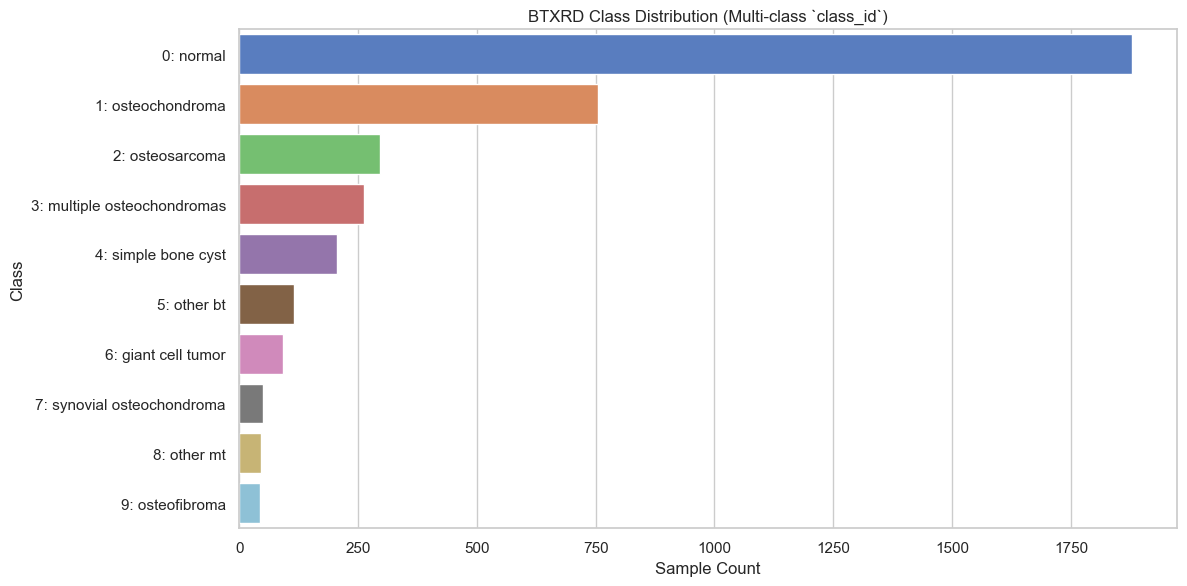

Class Frequencies:
Class 0 (normal                   ): 1879 (50.2%)
Class 1 (osteochondroma           ):  754 (20.1%)
Class 2 (osteosarcoma             ):  297 (7.9%)
Class 3 (multiple osteochondromas ):  263 (7.0%)
Class 4 (simple bone cyst         ):  206 (5.5%)
Class 5 (other bt                 ):  115 (3.1%)
Class 6 (giant cell tumor         ):   93 (2.5%)
Class 7 (synovial osteochondroma  ):   50 (1.3%)
Class 8 (other mt                 ):   45 (1.2%)
Class 9 (osteofibroma             ):   44 (1.2%)


In [3]:
classes = [
    'normal', 'osteochondroma', 'osteosarcoma', 'multiple osteochondromas',
    'simple bone cyst', 'other bt', 'giant cell tumor', 'synovial osteochondroma',
    'other mt', 'osteofibroma'
]

if 'class_id' in df_btxrd.columns:
    class_counts = df_btxrd['class_id'].value_counts().sort_index()
    class_names = [f"{i}: {classes[i]}" for i in class_counts.index]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_counts.values, y=class_names, hue=class_names, legend=False)
    plt.title("BTXRD Class Distribution (Multi-class `class_id`)")
    plt.xlabel("Sample Count")
    plt.ylabel("Class")
    plt.tight_layout()
    plt.show()
    
    # Print table
    print("Class Frequencies:")
    for idx, count in zip(class_counts.index, class_counts.values):
        print(f"Class {idx} ({classes[idx]:25s}): {count:4d} ({count/len(df_btxrd)*100:.1f}%)")
else:
    print("`class_id` column not found in btxrd-labels.csv.")

### 2.3 Legacy Multi-label Pathology Frequencies

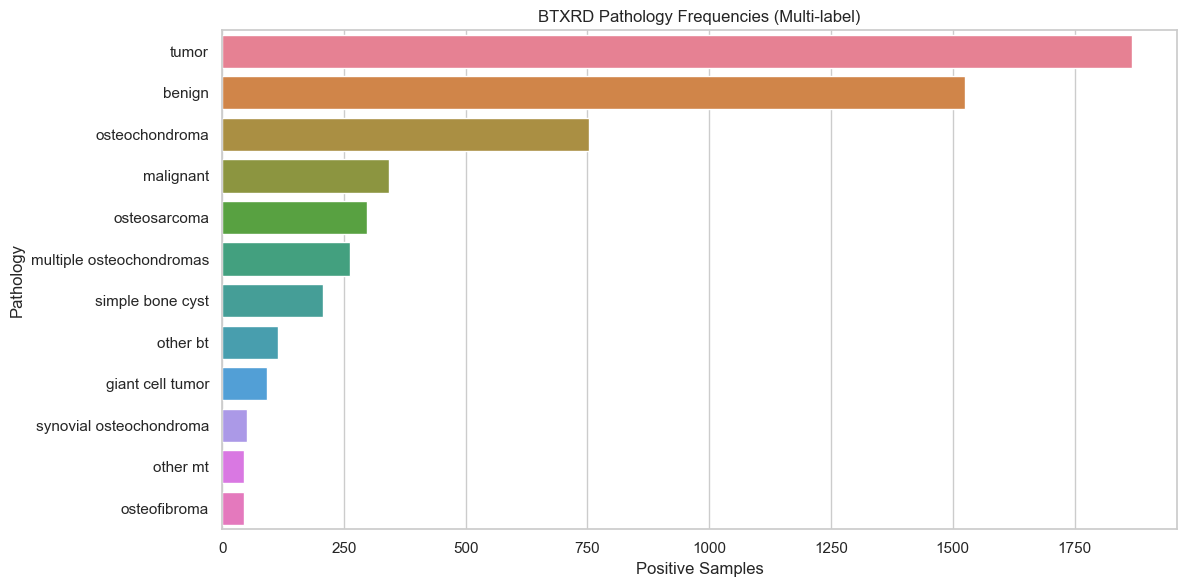

In [4]:
pathologies = [
    'tumor', 'benign', 'malignant', 'osteochondroma',
    'multiple osteochondromas', 'simple bone cyst', 'giant cell tumor',
    'osteofibroma', 'synovial osteochondroma', 'other bt',
    'osteosarcoma', 'other mt'
]

label_counts = df_btxrd[pathologies].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, legend=False)
plt.title("BTXRD Pathology Frequencies (Multi-label)")
plt.xlabel("Positive Samples")
plt.ylabel("Pathology")
plt.tight_layout()
plt.show()

### 2.4 Demographic Statistics (Age & Gender)

ValueError: Could not interpret value `age` for `x`. An entry with this name does not appear in `data`.

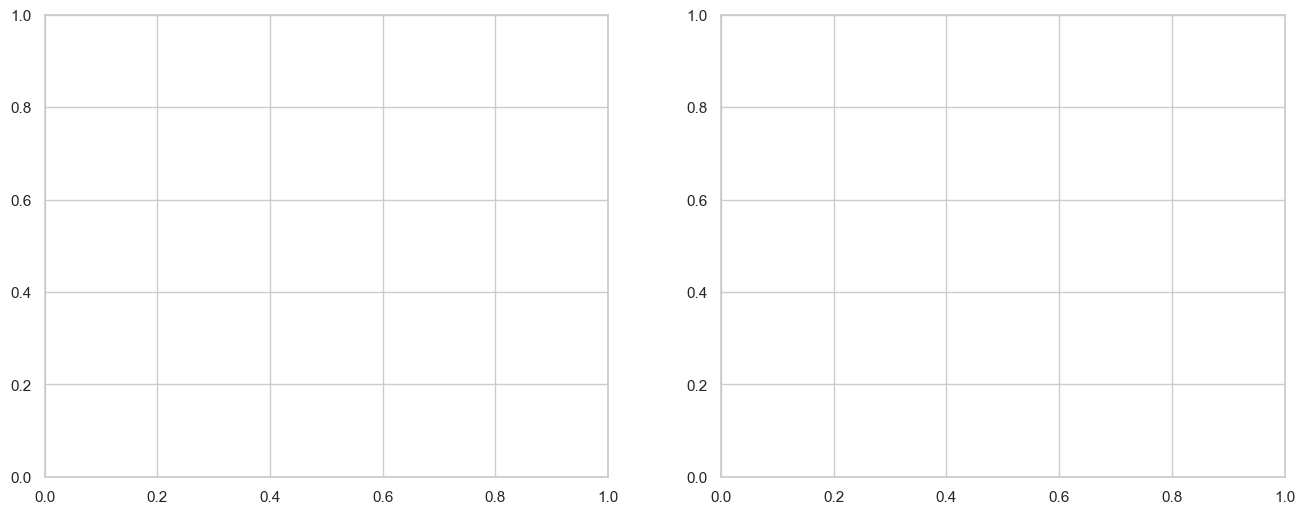

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution
sns.histplot(data=df_btxrd, x="age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("BTXRD Age Distribution")
axes[0].set_xlabel("Age")

# Gender distribution
gender_counts = df_btxrd['gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['pink', 'lightblue'])
axes[1].set_title("BTXRD Gender Distribution")

plt.tight_layout()
plt.show()

### 2.5 Using the BTXRDDataset Class

In [ ]:
btxrd_dataset = BTXRDDataset(
    img_dir="../data/BTXRD/images",
    report_dir="../data/BTXRD/reports",
    csv_split_path=btxrd_split_path,
    csv_labels_path=btxrd_labels_path,
    classes=classes,
    task_type="multiclass",
    split="train"
)

# Fetch a sample
idx = 10
img, report, label = btxrd_dataset[idx]

print("--- Sample Information ---")
print(f"Image Type      : {type(img)}")
print(f"Label (Class ID): {label.item()} ({classes[label.item()]})")
print(f"Report Text     : {report}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Sample {idx}: {classes[label.item()]}")
plt.axis("off")
plt.show()

## 3. Exploration of CTCH Dataset

CTCH is a bone disease dataset with clinical histories and X-ray findings reports for each sample.

### 3.1 Load Metadata and Splits

In [ ]:
ctch_labels_path = "../data/CTCH/ctch-labels.csv"
ctch_split_path = "../data/CTCH/ctch-split.csv"

if os.path.exists(ctch_labels_path):
    df_ctch = pd.read_csv(ctch_labels_path)
    df_ctch_split = pd.read_csv(ctch_split_path)
    df_ctch_merged = pd.merge(df_ctch_split, df_ctch, on="image_id", how="inner")
    
    print(f"Total merged CTCH samples: {len(df_ctch_merged)}")
    print(f"Columns: {list(df_ctch_merged.columns)}")
    display(df_ctch_merged.head())
else:
    print("CTCH metadata files not found.")

### 3.2 Pathology Frequencies (Multi-label)

In [ ]:
ctch_pathologies = [
    'fracture', 'dislocation', 'bone_tumor', 'infection', 'undetermined',
    'upper_limb_fracture', 'lower_limb_fracture', 'spine_fracture',
    'other_fracture', 'benign_bone_tumor', 'malignant_bone_tumor'
]

if os.path.exists(ctch_labels_path):
    ctch_counts = df_ctch_merged[ctch_pathologies].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=ctch_counts.values, y=ctch_counts.index, hue=ctch_counts.index, legend=False)
    plt.title("CTCH Pathology Frequencies (Multi-label)")
    plt.xlabel("Positive Samples")
    plt.ylabel("Pathology")
    plt.tight_layout()
    plt.show()

### 3.3 Using the CTCHDataset Class (Dual Reports)

CTCH supports loading dual text resources per sample: xray findings report and clinical history report.

In [ ]:
if os.path.exists(ctch_labels_path):
    ctch_dataset = CTCHDataset(
        img_dir="../data/CTCH/images",
        csv_split_path=ctch_split_path,
        csv_labels_path=ctch_labels_path,
        pathologies=ctch_pathologies,
        xray_report_dir="../data/CTCH/reports/xray",
        clinical_report_dir="../data/CTCH/reports/clinical",
        split="train"
)
    
    # Fetch a sample
    idx = min(5, len(ctch_dataset) - 1)
    img, xray_report, clinical_report, labels = ctch_dataset[idx]
    
    print("--- Sample Information ---")
    print(f"Image Type       : {type(img)}")
    print(f"Labels Vector    : {labels}")
    
    active_labels = [ctch_pathologies[i] for i, val in enumerate(labels) if val == 1.0]
    print(f"Active Pathologies: {active_labels}")
    
    print(f"\n[X-Ray Findings Report] (Phase 1 Source):\n{xray_report}")
    print(f"\n[Clinical History Report] (Phase 2 Source):\n{clinical_report}")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Sample {idx}: {', '.join(active_labels)}")
    plt.axis("off")
    plt.show()